In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

# 1. Universe & Data

In [2]:
from src.io import IO, YFinanceProvider
from src.domain.asset import PriceHistory

universe = IO().load_universe("jaime")
prices = YFinanceProvider().get_prices(universe.tickers, start="2010-01-01", end="2025-12-01")
history = PriceHistory(universe, prices)

print(f"Universe: {universe.tickers}")
print(f"Period: {history.dates[0].date()} -> {history.dates[-1].date()} ({len(history)} days)")

[*********************100%***********************]  21 of 21 completed
BOTZ: 1794 missing days (43.6%)
CIBR: 1494 missing days (36.3%)
DBA: 109 missing days (2.7%)
GLD: 109 missing days (2.7%)
IEF: 109 missing days (2.7%)
IEMA.L: 91 missing days (2.2%)
ITB: 109 missing days (2.7%)
IUSN.DE: 2180 missing days (53.0%)
IWDA.L: 91 missing days (2.2%)
LIT: 248 missing days (6.0%)
SLV: 109 missing days (2.7%)
SOXX: 109 missing days (2.7%)
TLT: 109 missing days (2.7%)
XEON.DE: 66 missing days (1.6%)
XLE: 109 missing days (2.7%)
XLF: 109 missing days (2.7%)
XLI: 109 missing days (2.7%)
XLK: 109 missing days (2.7%)
XLP: 109 missing days (2.7%)
XLU: 109 missing days (2.7%)
XLV: 109 missing days (2.7%)


Universe: ['IWDA.L', 'IEMA.L', 'IUSN.DE', 'XLK', 'XLF', 'XLV', 'XLE', 'XLP', 'XLI', 'XLU', 'SOXX', 'CIBR', 'BOTZ', 'LIT', 'ITB', 'SLV', 'DBA', 'IEF', 'GLD', 'TLT', 'XEON.DE']
Period: 2018-04-26 -> 2025-11-28 (1854 days)


# 2. Strategy Setup

In [3]:
from src.domain.portfolio import Portfolio
from src.domain import Broker
from src.strategy.merton import MertonStrategy
from src.strategy.buy_and_hold import BuyAndHoldStrategy
from src.strategy.merton_vol import MertonVolStrategy
from src.strategy.merton_mom import MertonMomentumStrategy
from src.strategy.merton_full import MertonFullStrategy

from src.models.estimators import JamesSteinMean, LedoitWolfCovariance, RollingSigma, BLOmegaMu

portfolio = Portfolio(initial_cash=10_000_000, max_leverage=2.0, allow_short=False)
broker = Broker(universe.transaction_costs)

mu_estimator = BLOmegaMu(JamesSteinMean())
cov_estimator = LedoitWolfCovariance()
sigma_estimator = RollingSigma()

merton = MertonStrategy(
    universe=universe,
    defensive_ticker="XEON.DE",
    gamma=0.3,
    rebalance_every=21,
    mu_estimator=mu_estimator,
    cov_estimator=cov_estimator,
)

merton_dn = MertonStrategy(
    universe=universe,
    defensive_ticker="XEON.DE",
    gamma=0.3,
    rebalance_every=21,
    mu_estimator=mu_estimator,
    cov_estimator=cov_estimator,
    use_dn_bands=True,
    band_scale=5.0,
)

merton_vol =  MertonVolStrategy(
    universe=universe,
    defensive_ticker="XEON.DE",
    gamma=0.3,
    mu_estimator=mu_estimator,
    cov_estimator=cov_estimator,
    sigma_estimator=sigma_estimator,
    rebalance_every=21,
    sigma_target=0.25,
    use_dn_bands=True,
    band_scale=4.5,
    max_risky_fraction=1
)

merton_mom = MertonMomentumStrategy(
    universe=universe,
    defensive_ticker="XEON.DE",
    gamma=0.3,
    mu_estimator=JamesSteinMean(),
    cov_estimator=LedoitWolfCovariance(),
    momentum_lookback=252,
    momentum_skip=21, 
    momentum_alpha_min=0.3,
    use_dn_bands=True,
    band_scale=2.0,
    max_risky_fraction=1.0,
)

from src.strategy.merton_custom import MertonCustomStrategy

winner = MertonCustomStrategy(
    universe=universe,
    defensive_ticker="XEON.DE",
    gamma=0.3,               # aversión al riesgo
    top_n=3,                 # solo los 5 mejores según Merton
    max_risky_fraction=1.0,  # 80% risky, 20% defensive
    rebalance_every=1,      # mensual
    band_scale=1.0,          # bandas DN anchas → menos turnover
    momentum_alpha_min=0.3,
)

from src.strategy.merton_dual_mom import MertonDualMomentumStrategy

merton_dualmom = MertonDualMomentumStrategy(
    universe=universe,
    defensive_ticker="XEON.DE",
    gamma=0.3,
    top_n=5,
    max_risky_fraction=1.0,
    rebalance_every=1,
    band_scale=3.0,
    momentum_lookback=252,   # 12 meses
    momentum_skip=21,        # excluir último mes
)


# 1. Buy & hold equal-weight (como antes)
bnh = BuyAndHoldStrategy(universe=universe, exclude="XEON.DE")

# 2. 60/40 (IWDA.L / XEON.DE)
bnh_60_40 = BuyAndHoldStrategy(
    universe=universe,
    weights={"IWDA.L": 0.6, "XEON.DE": 0.4},
    name="60_40",
)

# 3. Equal-weight rebalanceado mensual
bnh_rebal = BuyAndHoldStrategy(
    universe=universe,
    rebalance_every=21,
)

# 3. Run Backtest

In [4]:
from src.backtesting import Backtest

result = Backtest(
    portfolio=portfolio,
    universe=universe,
    strategies=[merton, merton_dualmom, merton_mom, winner, bnh, bnh_60_40, bnh_rebal],
    history=history,
    broker=broker,
    warmup_size=252,
).run()

# 4. Strategy Comparison

In [5]:
result.summary_df[["total_return", "annualized_return", "annualized_volatility", "sharpe_ratio", "max_drawdown", "calmar_ratio", "total_costs"]].round(4)

,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,calmar_ratio,total_costs
merton,1.5308,0.1573,0.2260,0.6957,-0.3687,0.4265,66352.5278
merton_dual_mom,3.5729,0.2701,0.2210,1.2223,-0.3757,0.7191,109487.9935
merton_mom,3.4434,0.2644,0.2218,1.1924,-0.2883,0.9171,115662.5384
merton_custom,2.2529,0.2039,0.1279,1.5944,-0.1505,1.3542,235059.9550
buy_and_hold,2.7521,0.2312,0.2745,0.8423,-0.4964,0.4658,5407.8229
60_40,0.8331,0.1000,0.1181,0.8467,-0.2180,0.4588,1143.9533
equal_weight_rebal,3.2989,0.2578,0.3047,0.8461,-0.5472,0.4712,44586.5829


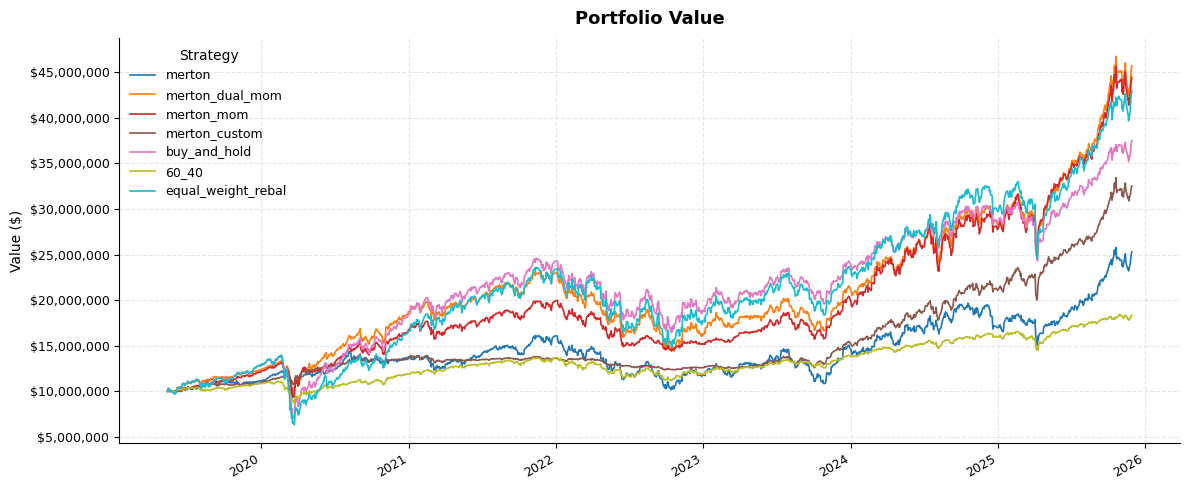

In [6]:
result.plot_value()

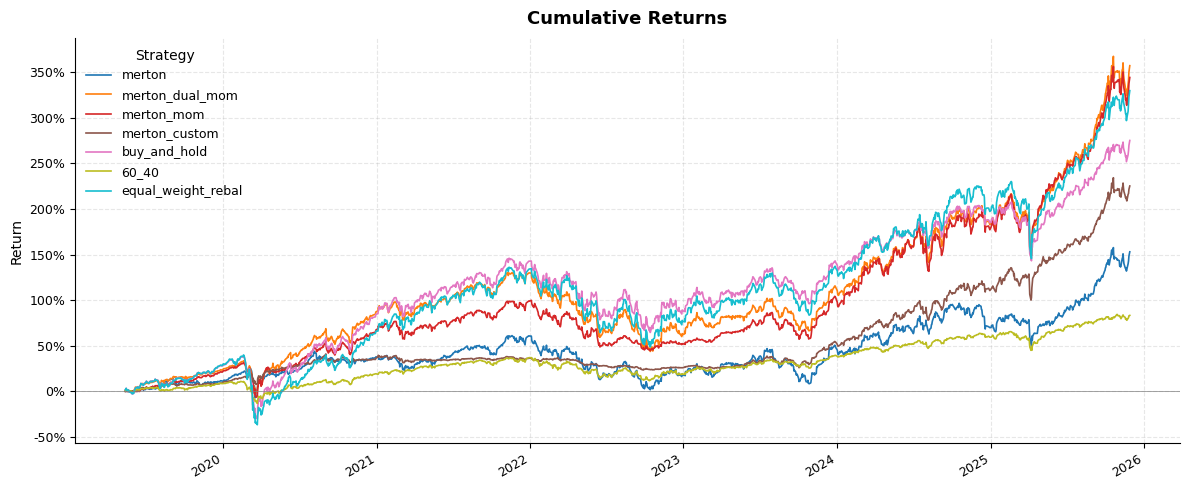

In [7]:
result.plot_returns()

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


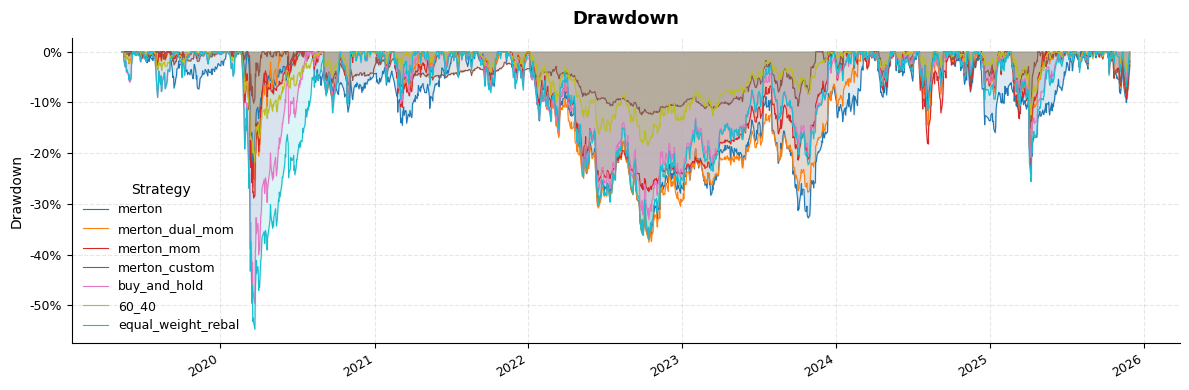

In [8]:
result.plot_drawdown()

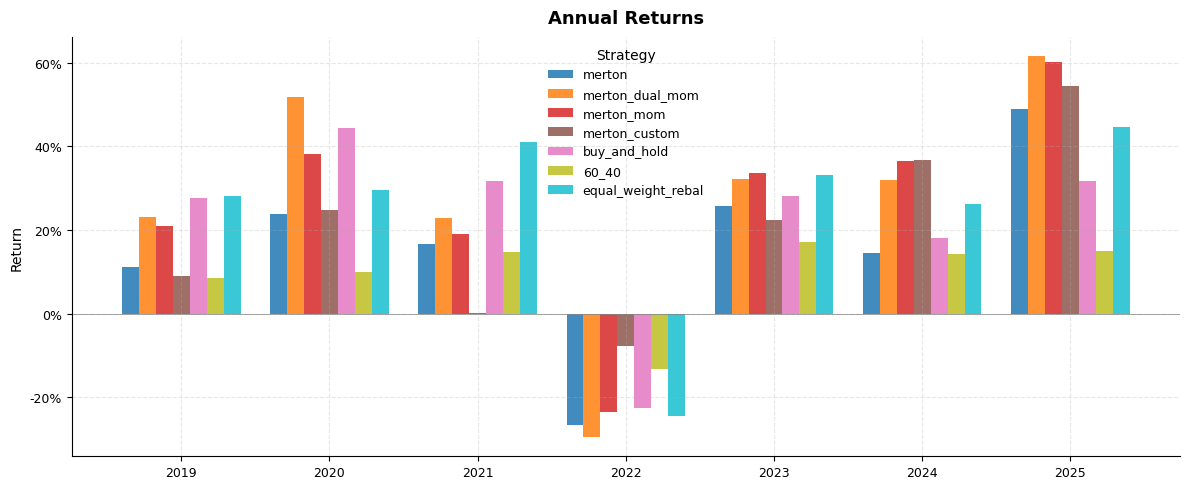

In [9]:
result.plot_annual_returns()

# 5. Rolling Metrics

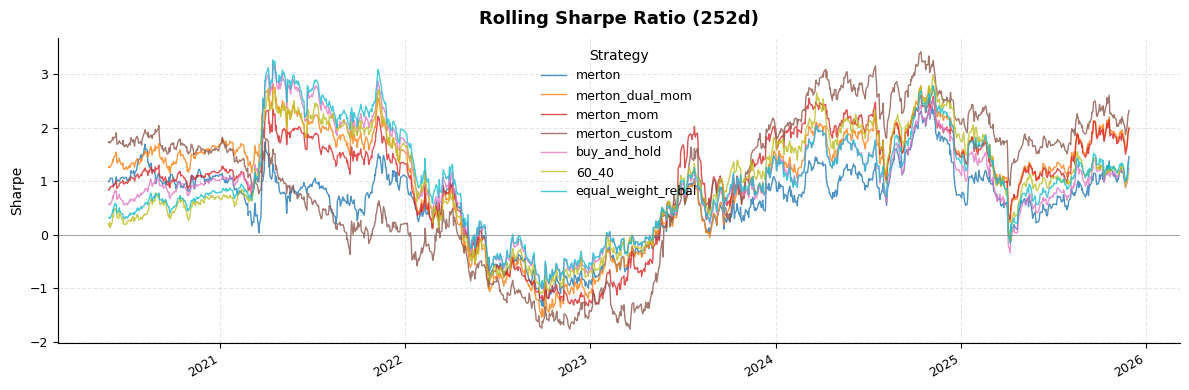

In [10]:
result.plot_rolling_sharpe()

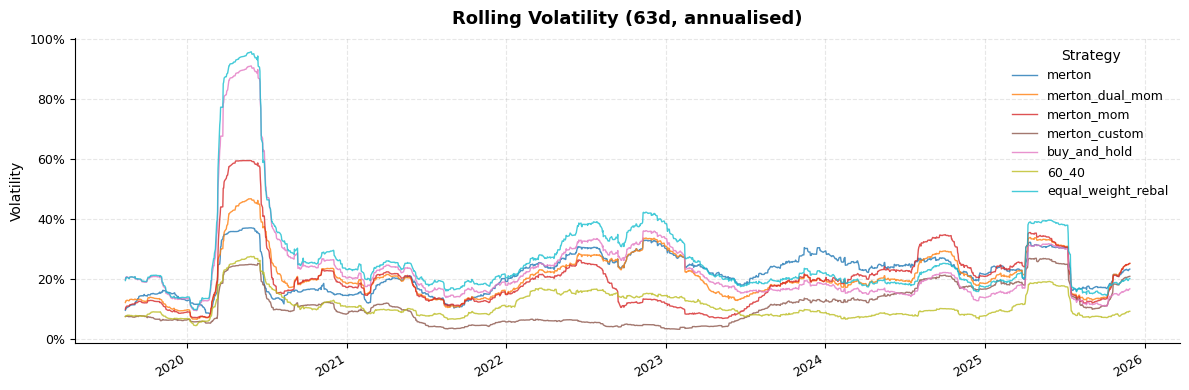

In [11]:
result.plot_rolling_volatility()

# 6. Individual Strategy Analysis

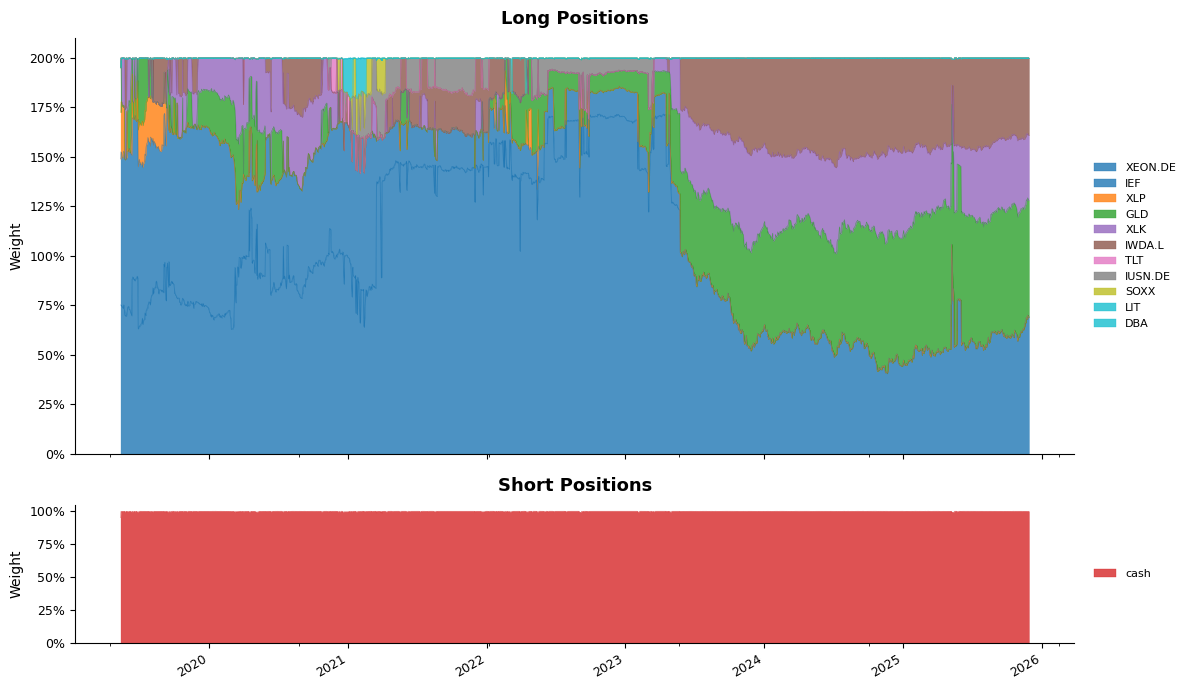

In [12]:
result.result("merton_custom").plot_weights()

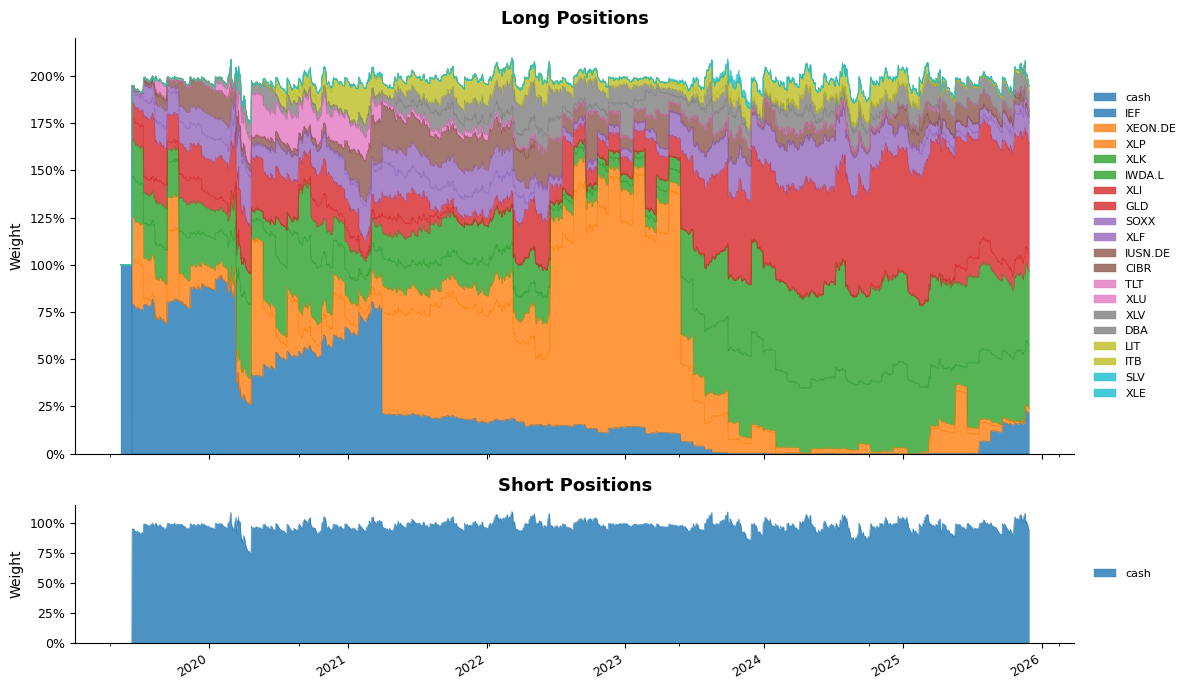

In [13]:
result.result("merton_mom").plot_weights()

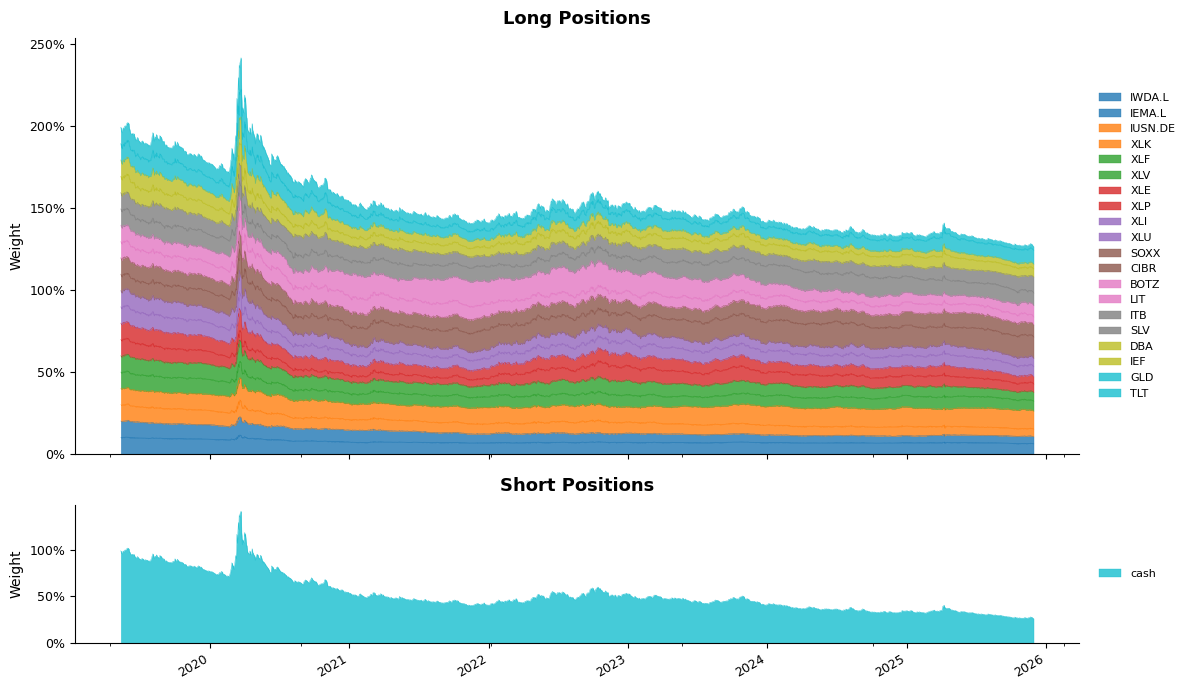

In [14]:
result.result("buy_and_hold").plot_weights()

# 7. Return Distributions

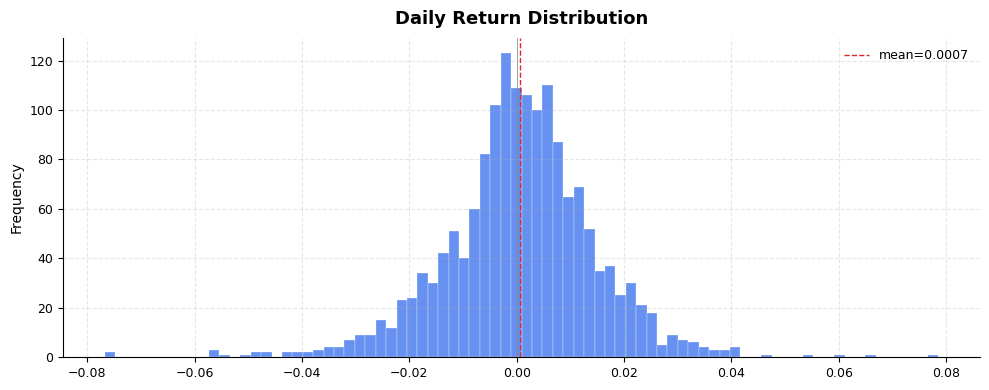

In [15]:
result.result("merton").plot_return_distribution()

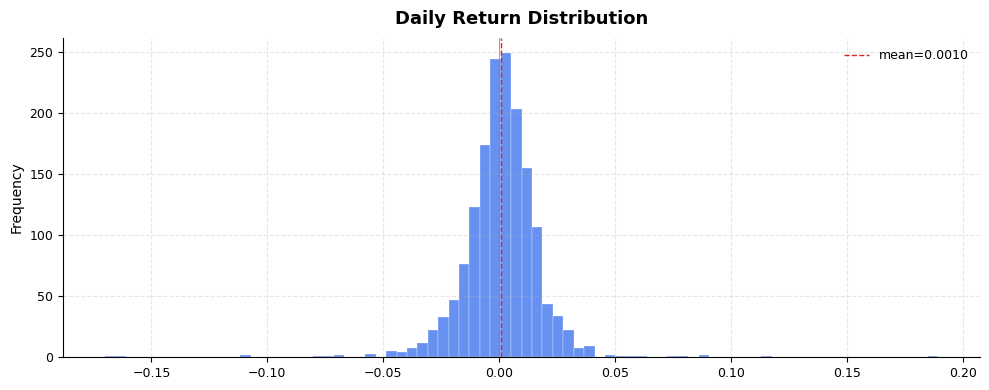

In [16]:
result.result("buy_and_hold").plot_return_distribution()

# 8. Monthly Returns Heatmaps

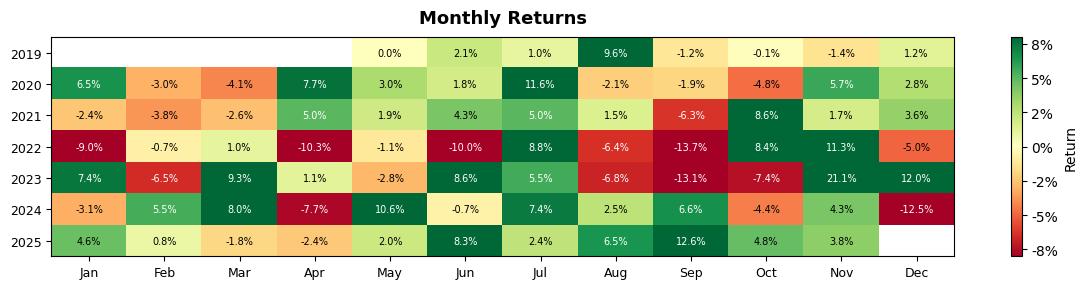

In [17]:
result.result("merton").plot_monthly_heatmap()

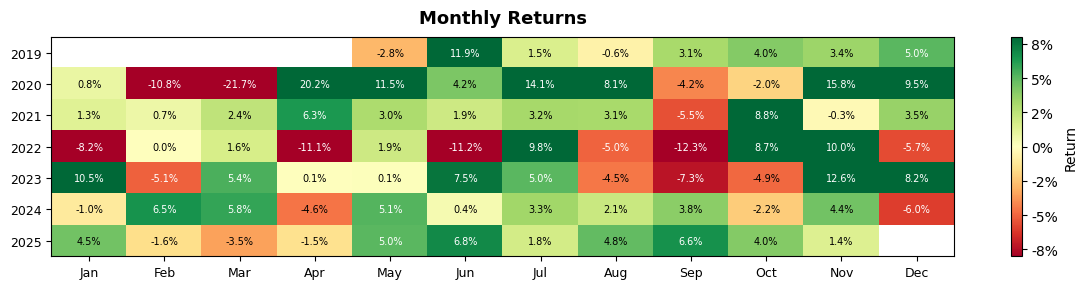

In [18]:
result.result("buy_and_hold").plot_monthly_heatmap()

# 9. Individual Rolling Metrics

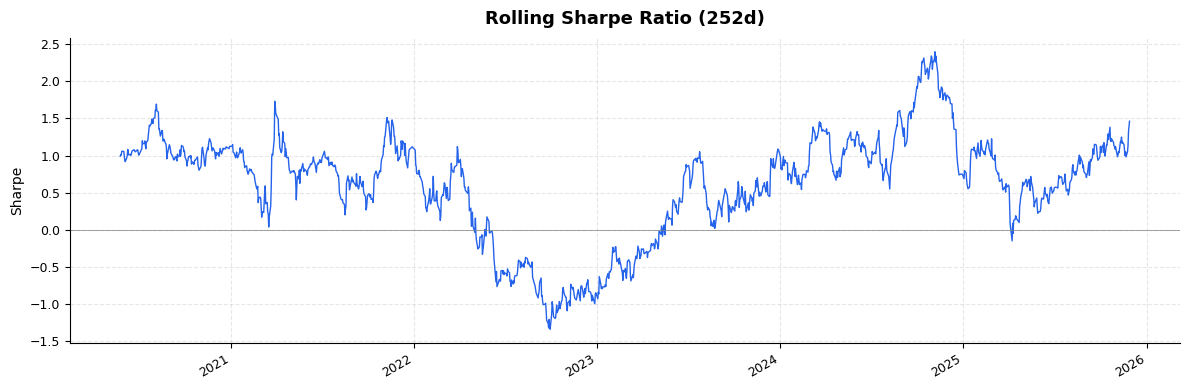

In [19]:
result.result("merton").plot_rolling_sharpe()

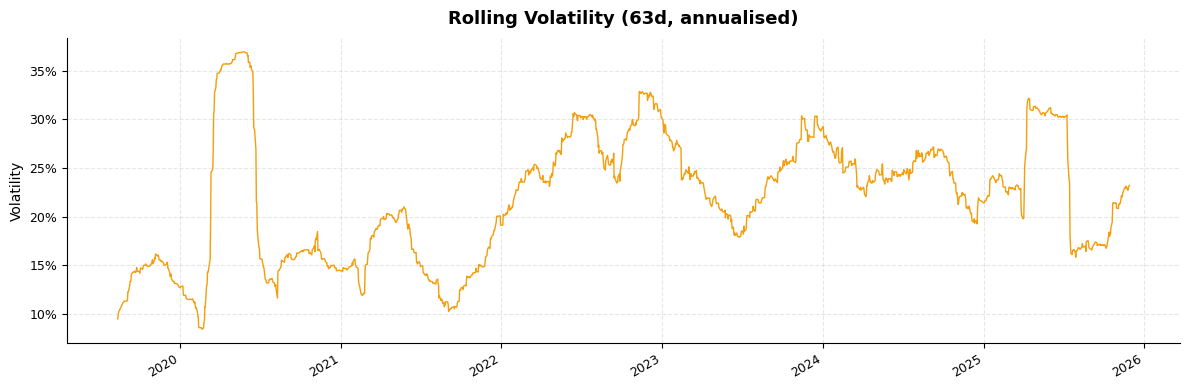

In [20]:
result.result("merton").plot_rolling_volatility()

# 10. Individual Annual Returns

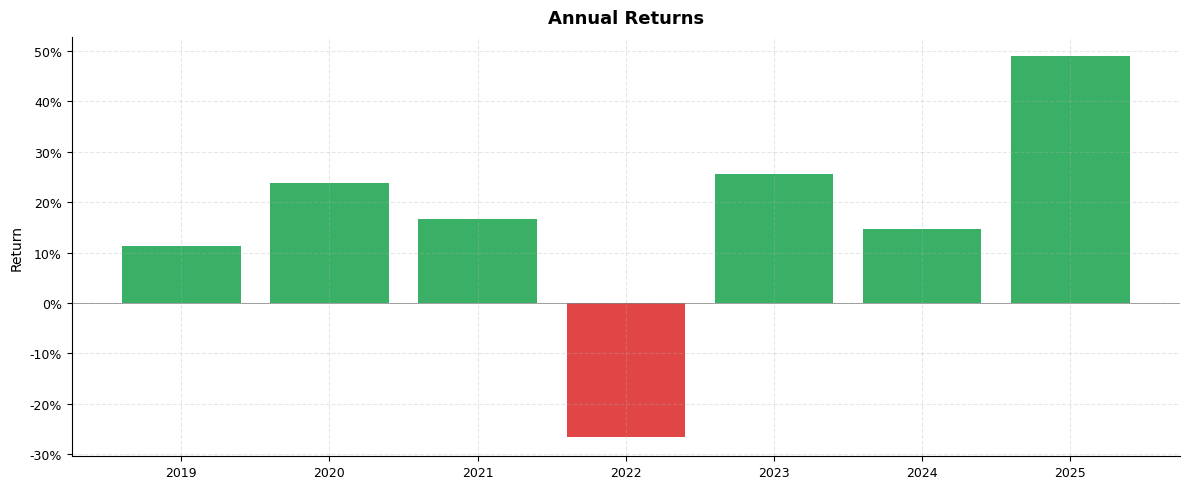

In [21]:
result.result("merton").plot_annual_returns()

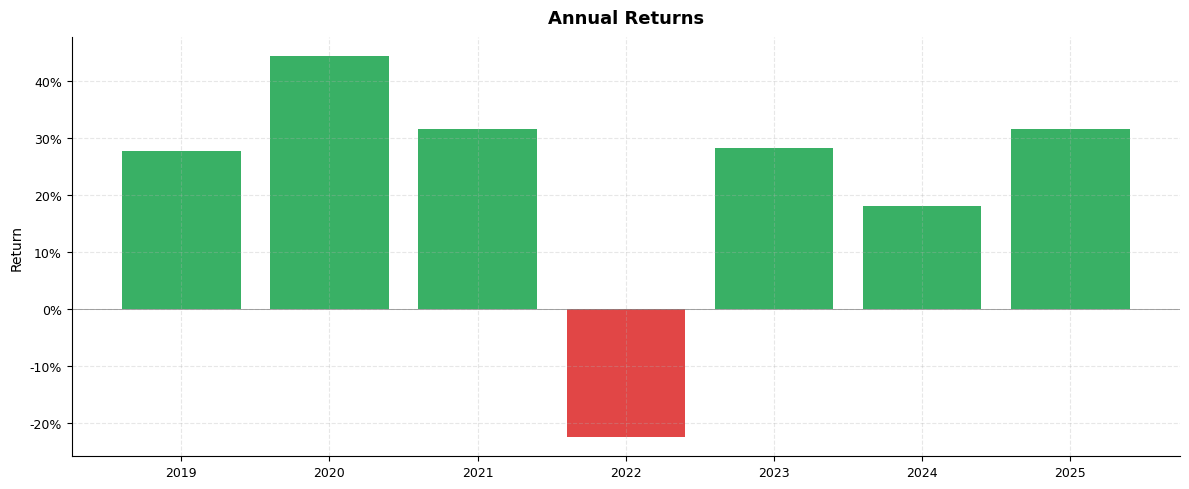

In [22]:
result.result("buy_and_hold").plot_annual_returns()

# 11. Trading Activity

In [23]:
for name in result.strategies:
    r = result.result(name).combined
    print(f"\n--- {name} ---")
    print(f"  Signals:  {r.total_signals}")
    print(f"  Orders:   {r.total_orders} (accepted={r.accepted_orders}, rejected={r.rejected_orders}, invalid={r.invalid_orders})")
    print(f"  Trades:   {r.total_trades}")
    print(f"  Costs:    ${r.total_costs:,.2f}")


--- merton ---
  Signals:  1806
  Orders:   1806 (accepted=1382, rejected=0, invalid=424)
  Trades:   1382
  Costs:    $66,352.53

--- merton_dual_mom ---
  Signals:  7125
  Orders:   7125 (accepted=6310, rejected=23, invalid=792)
  Trades:   6310
  Costs:    $109,487.99

--- merton_mom ---
  Signals:  1454
  Orders:   1454 (accepted=1033, rejected=0, invalid=421)
  Trades:   1033
  Costs:    $115,662.54

--- merton_custom ---
  Signals:  6136
  Orders:   6136 (accepted=5885, rejected=0, invalid=251)
  Trades:   5885
  Costs:    $235,059.96

--- buy_and_hold ---
  Signals:  20
  Orders:   20 (accepted=20, rejected=0, invalid=0)
  Trades:   20
  Costs:    $5,407.82

--- 60_40 ---
  Signals:  2
  Orders:   2 (accepted=2, rejected=0, invalid=0)
  Trades:   2
  Costs:    $1,143.95

--- equal_weight_rebal ---
  Signals:  1617
  Orders:   1617 (accepted=1612, rejected=5, invalid=0)
  Trades:   1612
  Costs:    $44,586.58


In [29]:
merton_dual_mom_orders = result.result("merton_dual_mom").window(0).orders_df

merton_dual_mom_orders[merton_dual_mom_orders["status"] == "rejected"]

,date,ticker,direction,shares,price,value,status,signal_reason,reason
912,2020-03-09,TLT,sell,-1996.119374,143.179367,285803.108569,rejected,merton,short selling not allowed
919,2020-03-10,TLT,sell,-742.425556,135.840210,100851.243342,rejected,merton,short selling not allowed
932,2020-03-12,TLT,sell,-1453.313475,131.652405,191332.213861,rejected,merton,short selling not allowed
943,2020-03-16,TLT,sell,-605.216363,137.010422,82920.949203,rejected,merton,short selling not allowed
950,2020-03-17,TLT,sell,-71.511921,127.874191,9144.529128,rejected,merton,short selling not allowed
956,2020-03-18,TLT,sell,-638.249565,120.660439,77011.472413,rejected,merton,short selling not allowed
961,2020-03-19,TLT,sell,-137.184387,123.945488,17003.385752,rejected,merton,short selling not allowed
4115,2023-10-19,XLE,sell,-514.636681,42.305237,21771.826672,rejected,merton,short selling not allowed
5645,2024-10-31,CIBR,sell,-478.134051,59.710075,28549.420209,rejected,merton,short selling not allowed
5844,2024-12-19,DBA,sell,-7149.298886,25.342634,181182.066469,rejected,merton,short selling not allowed


In [38]:
merton_dual_mom_snapshots = result.result("merton_dual_mom").window(0).snapshots_df

merton_dual_mom_snapshots.loc["2020-10-19","XLE_shares"]

nan

In [25]:
result.result("merton_custom").window(0).orders_df.tail(20)

,date,ticker,direction,shares,price,value,status,signal_reason,reason
6116,2025-11-18,XEON.DE,buy,1937.544884,147.733002,286239.321594,accepted,defensive,None
6117,2025-11-19,XEON.DE,buy,665.113820,147.727997,98255.932335,accepted,defensive,None
6118,2025-11-20,IWDA.L,sell,-1262.085467,126.010002,159035.392386,accepted,merton,None
6119,2025-11-20,XEON.DE,sell,-739.273270,147.733994,109215.792539,accepted,defensive,None
6120,2025-11-21,GLD,sell,-598.763487,374.269989,224099.203613,accepted,merton,None
6121,2025-11-21,IWDA.L,sell,-3069.087378,124.349998,381641.010787,accepted,merton,None
6122,2025-11-21,XLK,sell,-2020.785510,136.223755,275278.989933,accepted,merton,None
6123,2025-11-21,XEON.DE,buy,4802.153112,147.720001,709374.063540,accepted,defensive,None
6124,2025-11-24,XEON.DE,buy,1109.881530,147.733002,163966.130012,accepted,defensive,None
6125,2025-11-24,GLD,buy,807.163715,380.200012,306883.654332,accepted,merton,None


# 12. Target vs Actual Weights (Merton)

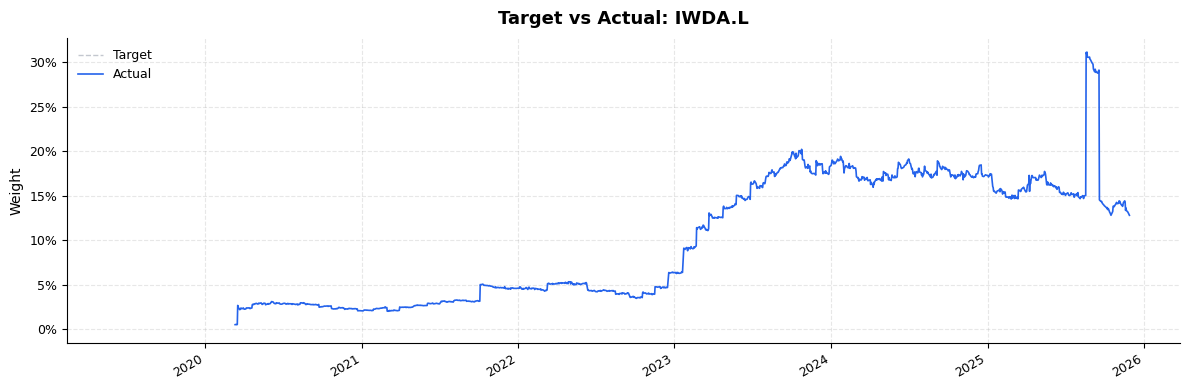

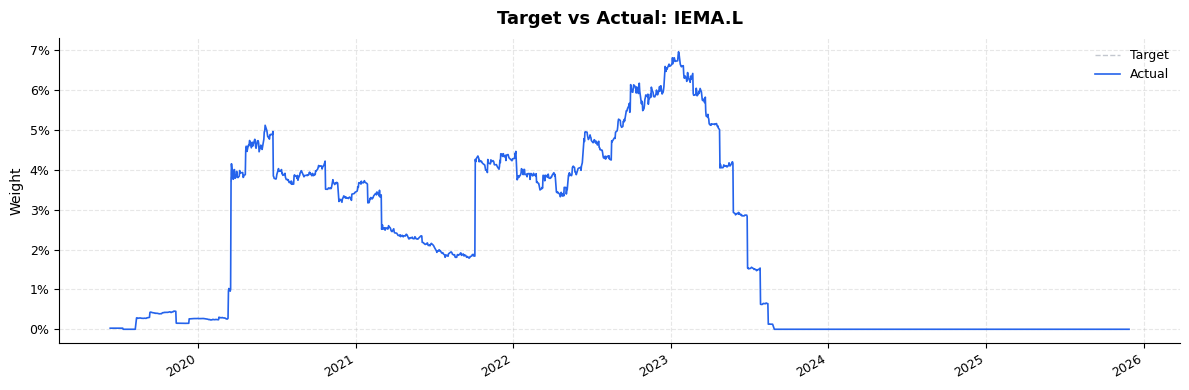

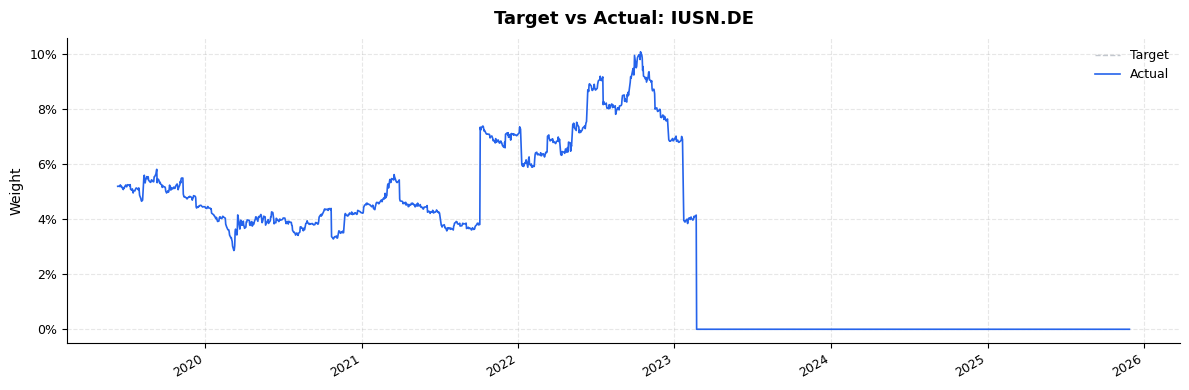

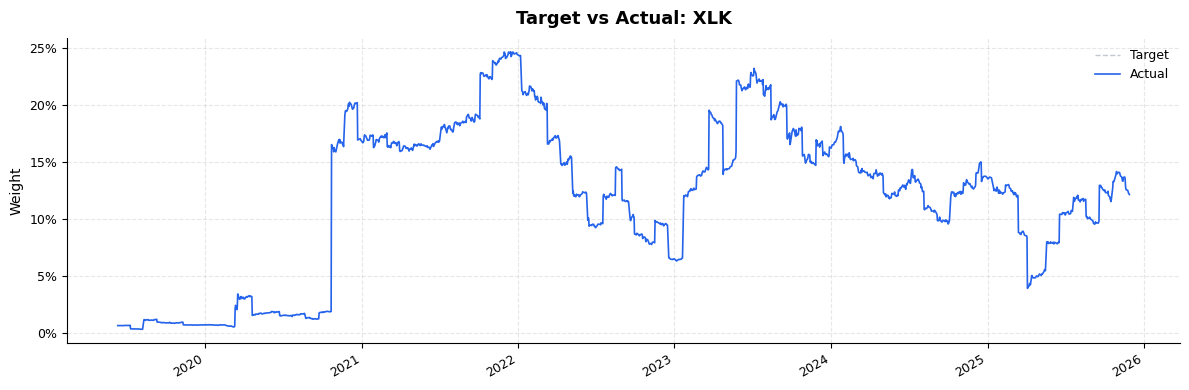

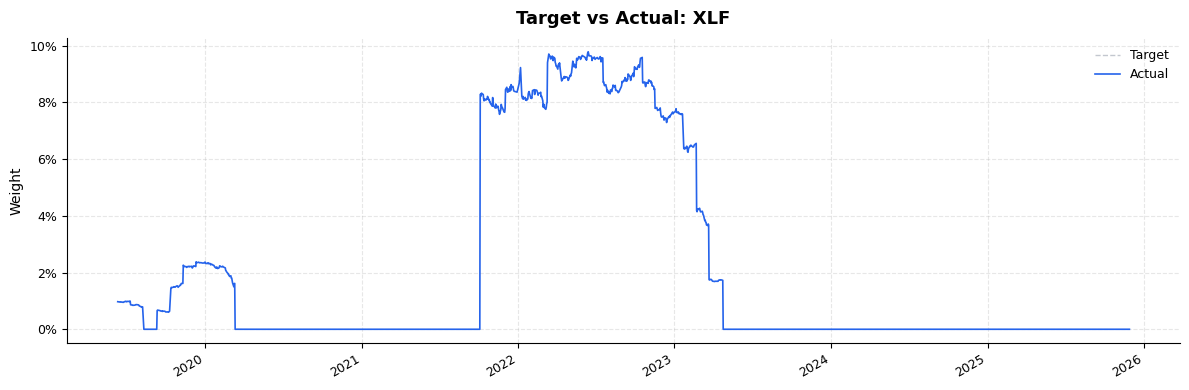

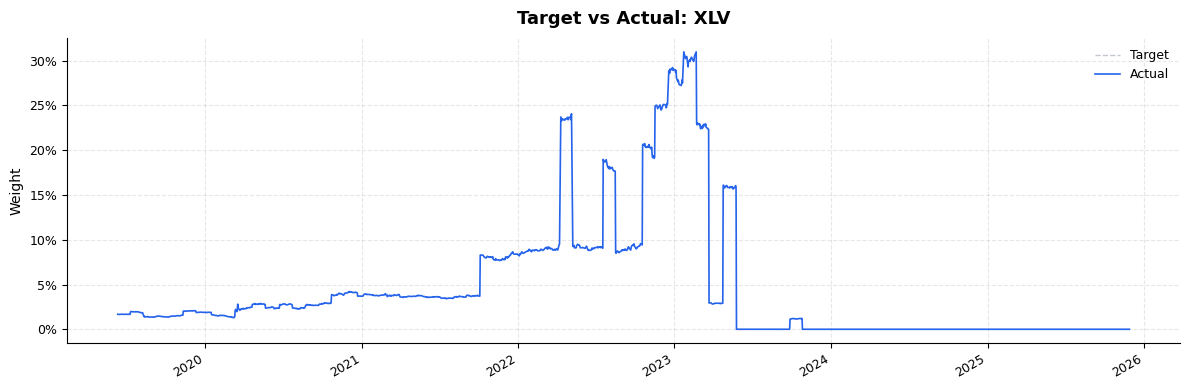

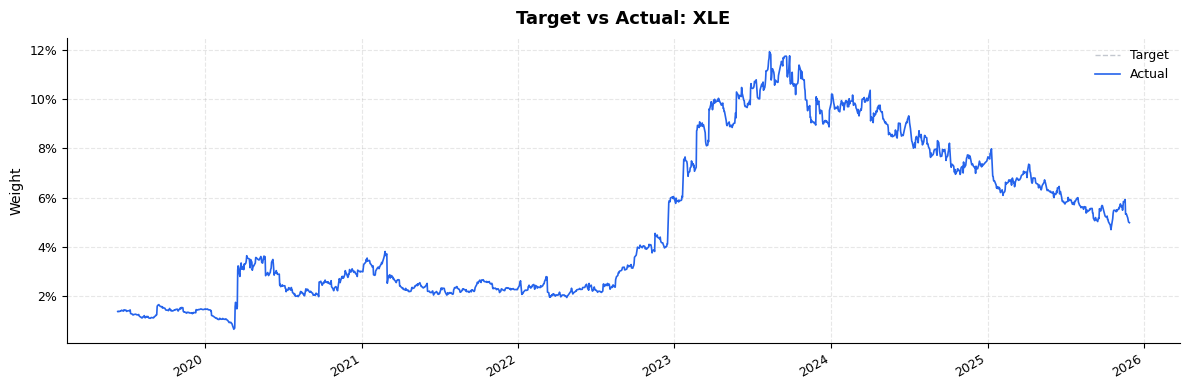

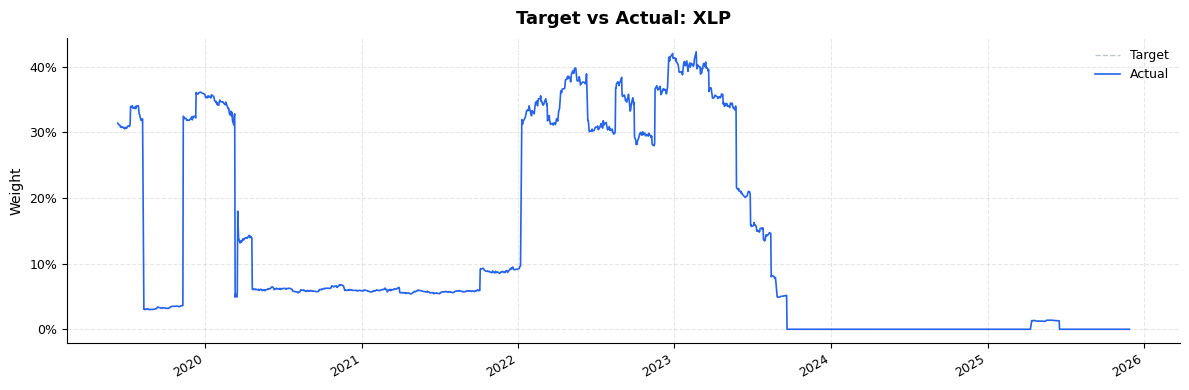

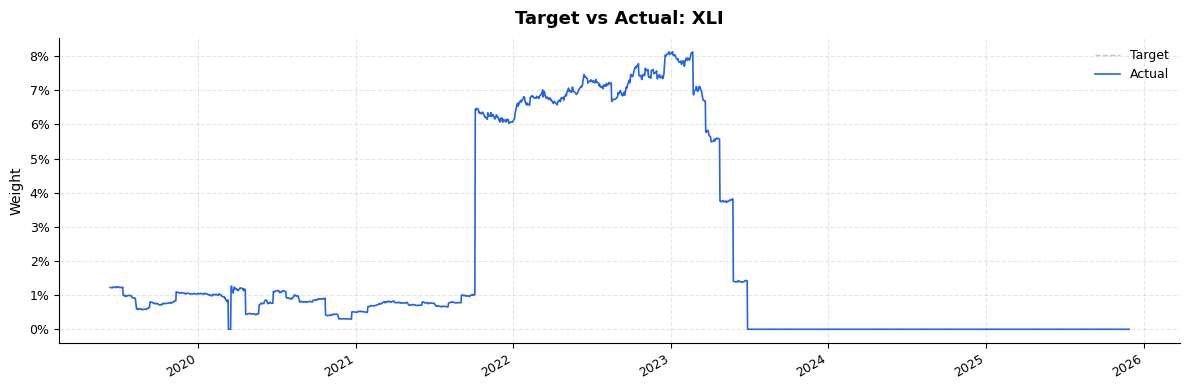

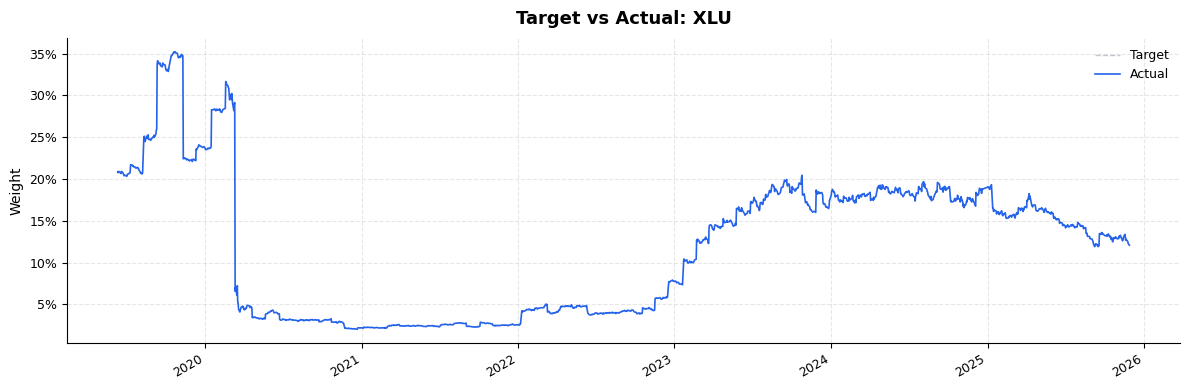

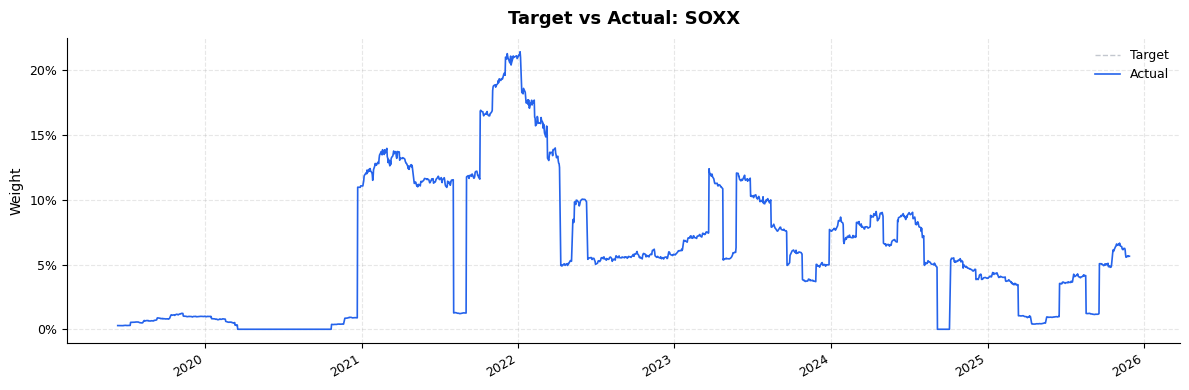

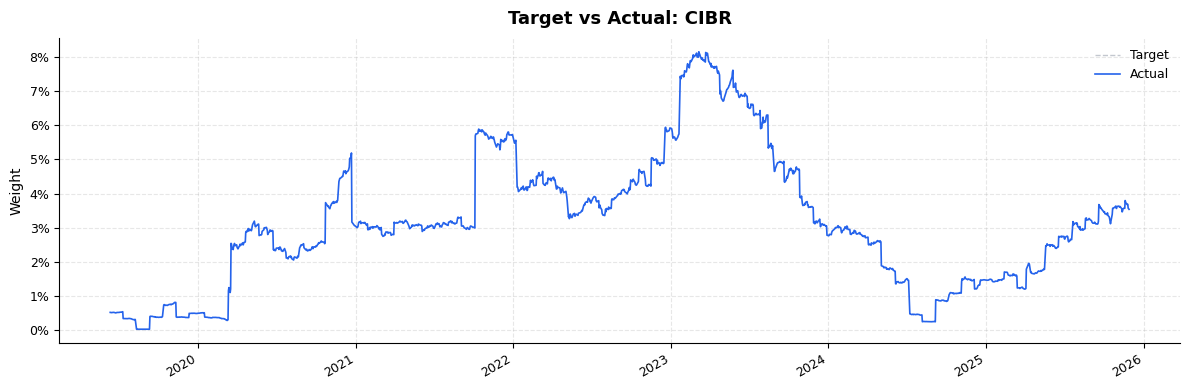

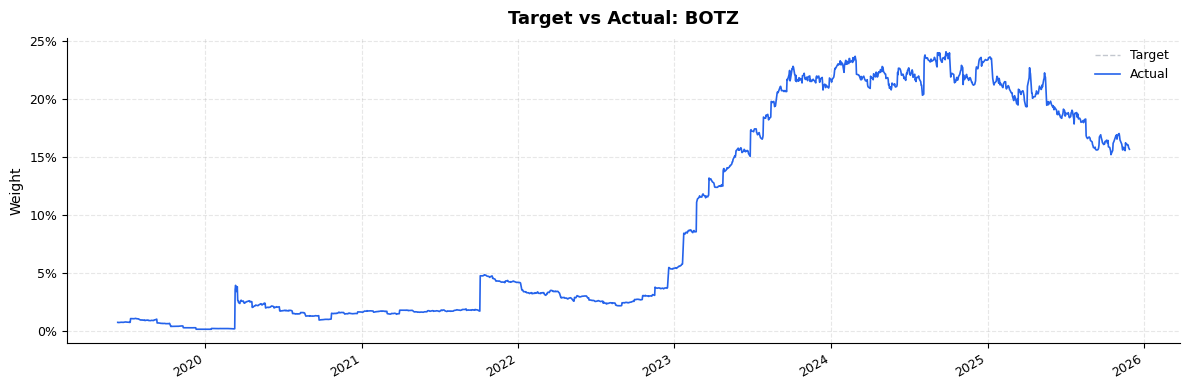

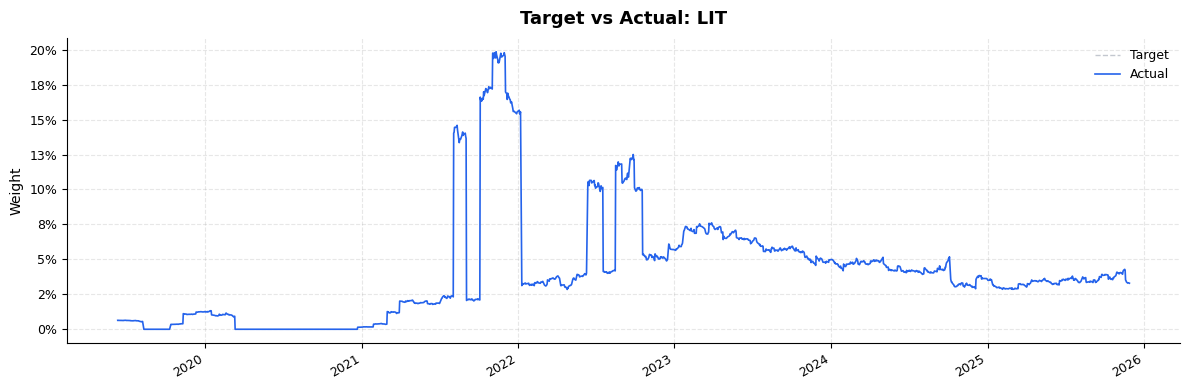

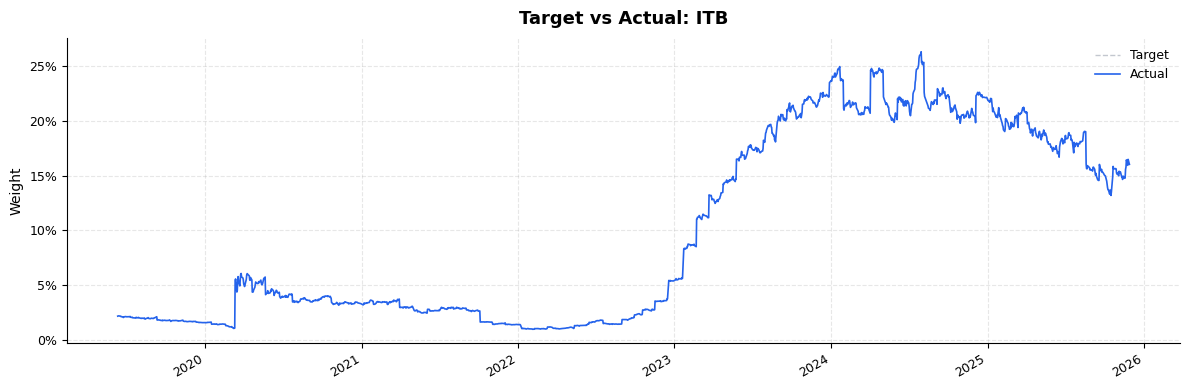

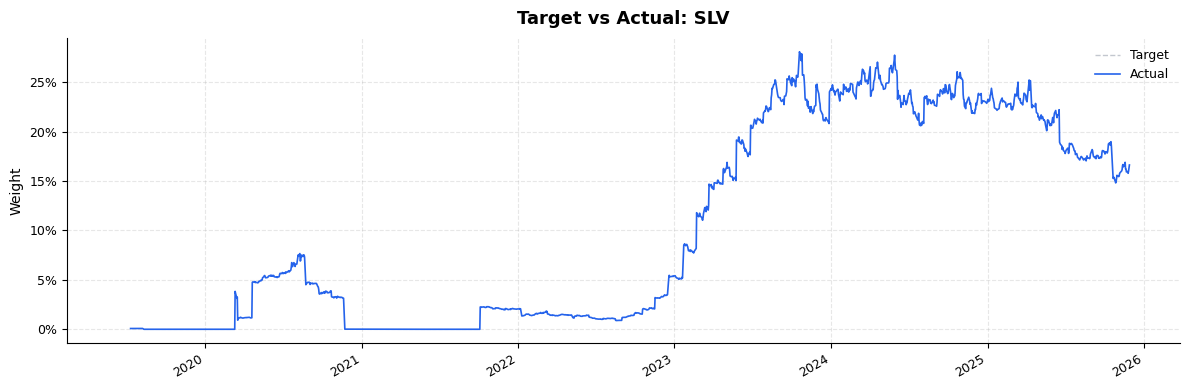

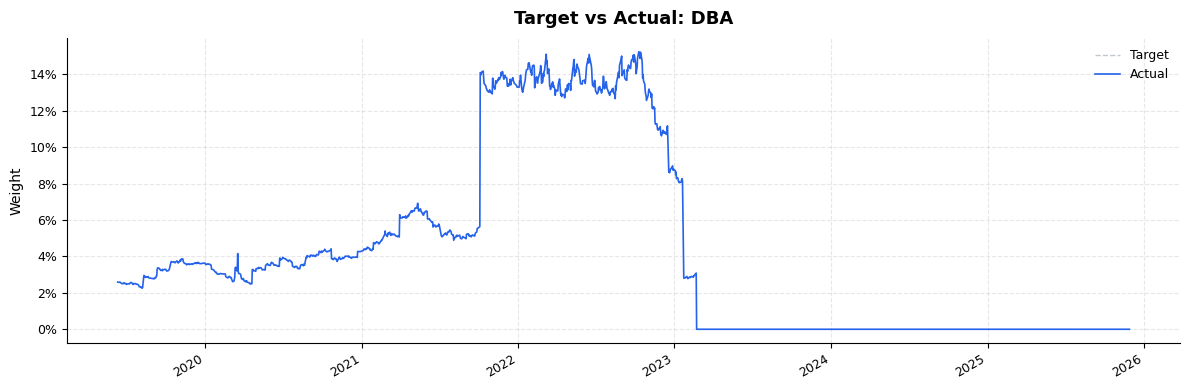

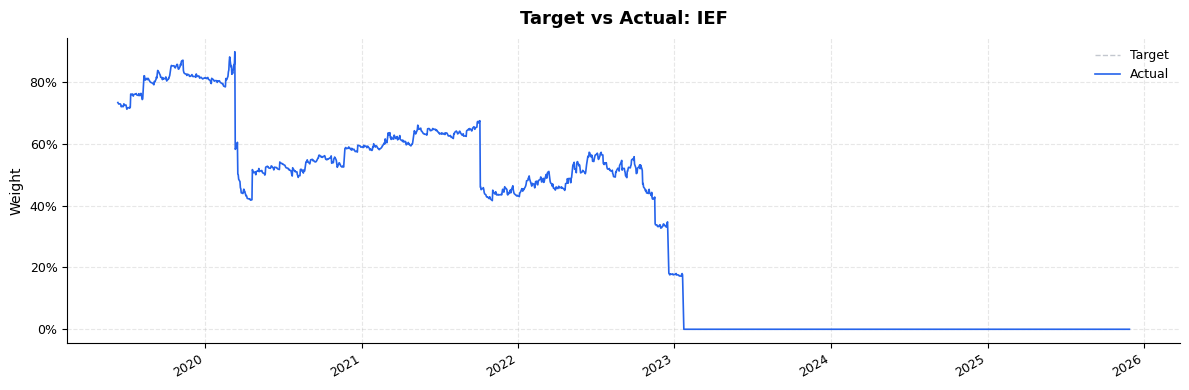

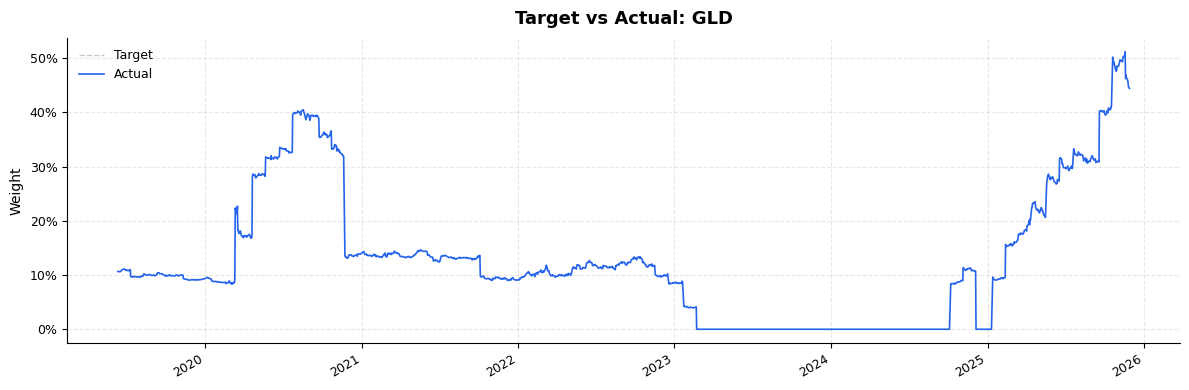

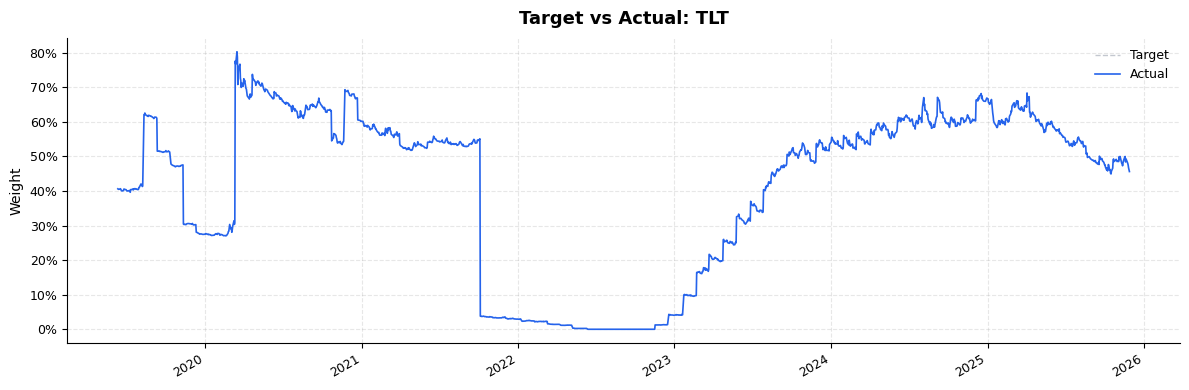

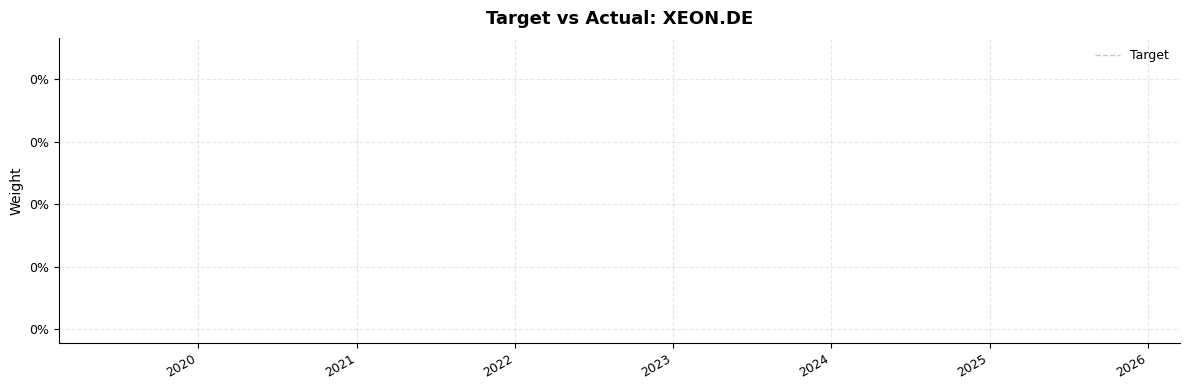

In [26]:
for ticker in universe.tickers:
    result.result("merton").plot_target_vs_actual(ticker)